# 00 · Setup directories — anatomy, inspection & authoring

Everything the simulator runs starts from a **setup directory**: a plain folder with
exactly two files.

| file | what it holds |
|---|---|
| `catalog.csv` | one row per SKU — `product_id, name, category, base_price, unit_cost, seasonality` |
| `setup.yaml`  | the `run:`, `market:`, `disruption:`, `nodes:` and `edges:` blocks |

`load_setup(dir)` reads both, validates them, derives every seed from a single
`world_seed`, wires up policies, and hands back an in-memory `Scenario`. This notebook
loads a bundled setup, walks every inspection surface, then shows the two ways to
**author a new one** — scaffolding a topology from a catalog, and round-tripping a
`Scenario` back to disk.

> New paradigm note: the old `World` artifact / `world_to_graph` flow is gone. A setup
> directory *is* the scenario now.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and relative paths like
# `setups/three_node_chain` resolve no matter where the kernel started.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## 1 · Load a bundled setup directory

`setups/three_node_chain` is the minimal example: one factory → one shop → one demand sink, 2 products, 30 ticks. No API key required.

In [2]:
from src.sim.setup_io import load_setup

scenario = load_setup("setups/three_node_chain")
scenario.summary_df().T

,0
n_steps,30
start_date,2024-01-01 00:00:00
world_seed,42
n_products,1
n_nodes,3
n_DemandSinkNode,1
n_FactoryNode,1
n_IntermediateNode,1


### The raw files on disk

A setup directory is hand-readable. Here are the two files verbatim.

In [3]:
print("── catalog.csv ──")
print(Path("setups/three_node_chain/catalog.csv").read_text())

── catalog.csv ──
product_id,name,category,base_price,unit_cost,seasonality,related_products,init_stock_share
P0001,Widget A,widgets,12.50,5.00,peak,,1.0



In [4]:
print("── setup.yaml ──")
print(Path("setups/three_node_chain/setup.yaml").read_text())

── setup.yaml ──
# Three-node chain example setup.
# Topology: factory-1 → shop-1 → sink-1
# No API key required. Run with:
#   uv run python main.py run setups/three_node_chain

run:
  n_steps: 30
  start_date: "2024-01-01"
  world_seed: 42

market:
  cycle_len: 30
  cycle_amp: 0.03
  init_demand: 1.0
  init_supply: 1.0
  peak_factor: 1.0
  off_factor: 1.0
  season_months:
    peak: [6, 7, 8]
  regions: [US]
  correlation: 0.5
  trend_update_interval: 100
  min_value: 0.5
  max_value: 2.0
  stage_multipliers: {}
  price_elasticity: 0.0
  promo_multiplier: 1.0
  demand_factor_min: 0.1
  supply_factor_min: 0.01
  cross_inv_lo: 0.3
  cross_inv_hi: 0.7
  cross_factor_range: [0.5, 1.5]
  trend: {kind: constant, value: 1.0}
  demand_shock: {kind: normal, mean: 0.0, std: 0.04}
  supply_shock: {kind: normal, mean: 0.0, std: 0.03}
  base_demand: {kind: constant, value: 10.0}

disruption:
  event_prob: 0.0
  types: [natural_disaster]
  regions: [US]
  severity: {kind: constant, value: 0.0}
  du

## 2 · Inspect the catalog (products)

`scenario.catalog_df()` is the tidy view of `catalog.csv`, plus a derived `margin` column.

In [5]:
scenario.catalog_df()[
    ["product_id", "name", "category", "base_price", "unit_cost", "margin", "seasonality"]
]

,product_id,name,category,base_price,unit_cost,margin,seasonality
0,P0001,Widget A,widgets,12.5,5.0,7.5,peak


## 3 · Inspect the topology (nodes & edges)

The graph is a validated DAG of typed nodes wired by supply edges.

In [6]:
display(scenario.nodes_df())
display(scenario.edges_df())

,node_id,node_type,region,init_seed,policy_class
0,factory-1,FactoryNode,US,3234706689,StaticFactoryPolicy
1,shop-1,IntermediateNode,US,98739437,OrderUpToPolicy
2,sink-1,DemandSinkNode,US,3754311622,DefaultDemandSinkPolicy


,supplier_id,buyer_id,default_lead_time
0,factory-1,shop-1,2
1,shop-1,sink-1,1


### Draw the DAG

We rebuild the structural `Graph`, compute each node's **display level** (0 = factory,
increasing toward the sinks via longest path), and lay the nodes out left-to-right by level.
`compute_levels` is a **display-only** hint — the engine schedules ticks by a demand-pull
walk of the graph (sinks first), not by echelon level, so a node's level carries no
functional meaning.

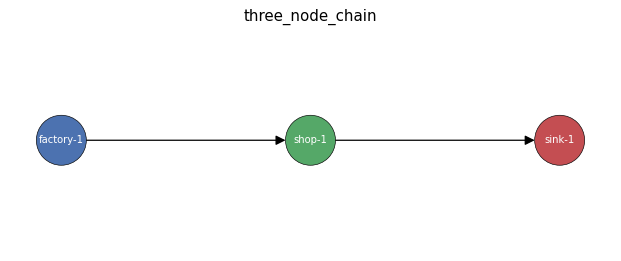

echelon levels: {'shop-1': 1, 'sink-1': 2, 'factory-1': 0}


In [7]:
import networkx as nx
from src.sim.graph import build_graph, compute_levels

def draw_topology(scenario, ax=None, title=""):
    node_ids = [ni.node.id for ni in scenario.nodes]
    graph = build_graph(node_ids, scenario.edges)
    levels = compute_levels(graph)
    ntype = {ni.node.id: type(ni.node).__name__ for ni in scenario.nodes}

    G = nx.DiGraph()
    for nid in node_ids:
        G.add_node(nid, subset=levels[nid])
    for e in scenario.edges:
        G.add_edge(e.supplier_id, e.buyer_id)

    pos = nx.multipartite_layout(G, subset_key="subset")
    color = {"FactoryNode": "#4C72B0", "IntermediateNode": "#55A868", "DemandSinkNode": "#C44E52"}
    colors = [color.get(ntype[n], "#888") for n in G.nodes]

    ax = ax or plt.gca()
    nx.draw_networkx(G, pos, ax=ax, node_color=colors, node_size=1600,
                     font_size=8, font_color="white", arrowsize=16,
                     edgecolors="black", linewidths=0.5)
    ax.set_title(title or "supply-chain DAG"); ax.axis("off")
    return levels

fig, ax = plt.subplots(figsize=(7, 3))
levels = draw_topology(scenario, ax=ax, title="three_node_chain")
plt.tight_layout(); plt.show()
print("echelon levels:", levels)

## 4 · Inspect the shared world (market & disruption)

Every node shares one stochastic world. These parameter bags drive regional supply/demand, seasonal cycles, and disruption events.

In [8]:
display(scenario.market_df().T.head(20))
display(scenario.disruption_df().T)

,0
cycle_len,30
cycle_amp,0.03
init_demand,1.0
init_supply,1.0
peak_factor,1.0
off_factor,1.0
season_months,"{'peak': [6, 7, 8]}"
regions,[US]
correlation,0.5
trend_update_interval,100


,0
event_prob,0.0
types,[natural_disaster]
regions,[US]
severity,Constant(value=0.0)
duration,Constant(value=1)


## 5 · Author a new setup — route A: scaffold a topology from a catalog

`scaffold_topology(catalog, spec)` emits a `nodes:`/`edges:` block in the exact format
`setup.yaml` expects — one factory per product, a shared shop, one sink per
(product × shop). Scaffolded and hand-written setups are indistinguishable.

In [9]:
from src.sim.topology_scaffolder import scaffold_topology, ScaffoldSpec

spec = ScaffoldSpec(shop_count=2, factory_capacity=120, shop_capacity=400, factory_lead_time=2)
block = scaffold_topology(scenario.catalog, spec)

print(f"scaffolded {len(block['nodes'])} nodes, {len(block['edges'])} edges")
import yaml
print(yaml.safe_dump({"nodes": block["nodes"][:3]}, sort_keys=False))

scaffolded 4 nodes, 2 edges
nodes:
- id: factory-p0001
  type: factory
  region: US
  produces_product_id: P0001
  unit_cost: 5.0
  capacity_per_tick: 120
  inventory: 0
  list_price: 5.0
  cash: 0.0
- id: shop-1
  type: intermediate
  region: US
  carried_products:
  - P0001
  capacity: 400
  tags:
  - shop
  inventory:
    P0001: 0
  list_prices:
    P0001: 12.5
  min_order_imposed:
    P0001: 0
  cash: 1000.0
- id: shop-2
  type: intermediate
  region: US
  carried_products: []
  capacity: 400
  tags:
  - shop
  inventory: {}
  list_prices: {}
  min_order_imposed: {}
  cash: 1000.0



The CLI wraps this as a one-liner that writes (or merges) straight into a `setup.yaml`:

```bash
uv run python main.py scaffold my_catalog.csv --out setups/my_run/setup.yaml
```

You then fill in `run:`, `market:`, and `disruption:` (or let the LLM generator draft
the market — see notebook **01**).

## 6 · Author a new setup — route B: round-trip a `Scenario` to disk

`write_setup(scenario, dir)` is the inverse of `load_setup`: it serialises a live
`Scenario` (catalog + every block + attached policies) back to a setup directory.
Re-loading it yields an equivalent scenario — handy for snapshotting an
experiment you built in memory.

In [10]:
from src.sim.setup_io import write_setup

out_dir = "data/notebook_demos/three_node_roundtrip"
write_setup(scenario, out_dir)
print("wrote:", sorted(p.name for p in Path(out_dir).iterdir()))

reloaded = load_setup(out_dir)
print("\nround-trip summary matches:",
      reloaded.summary_df().T.equals(scenario.summary_df().T))
reloaded.summary_df().T

wrote: ['catalog.csv', 'setup.yaml']

round-trip summary matches: True


,0
n_steps,30
start_date,2024-01-01 00:00:00
world_seed,42
n_products,1
n_nodes,3
n_DemandSinkNode,1
n_FactoryNode,1
n_IntermediateNode,1


## 7 · Run it (teaser)

A setup directory is all `Runner` needs. Here is the 30-tick run; notebook **02** dissects the outputs in full.

,,cash,inventory_total
node_type,node_id,,
DemandSinkNode,sink-1,4232.0,0
FactoryNode,factory-1,-500.0,200
IntermediateNode,shop-1,1118.0,104


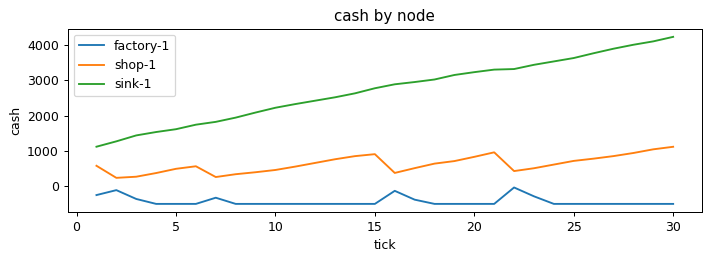

In [11]:
from src.sim.runner import Runner
from src.sim.inspect import node_timeseries_df

run_log = Runner(scenario).run()
ts = node_timeseries_df(run_log, scenario)

final = ts.sort_values("tick").groupby(["node_type", "node_id"]).last()
display(final[["cash", "inventory_total"]])

fig, ax = plt.subplots(figsize=(8, 3))
for nid, g in ts.groupby("node_id"):
    ax.plot(g["tick"], g["cash"], label=nid)
ax.set_xlabel("tick"); ax.set_ylabel("cash"); ax.set_title("cash by node")
ax.legend(); plt.tight_layout(); plt.show()

## Where to next

| notebook | topic |
|---|---|
| **01** | generate a catalog + market with the LLM world generator |
| **02** | run a simulation and inspect every output (tiers, equity, exported parquet) |
| **03** | topology gallery — build, draw, run & compare several DAG shapes |
| **04** | compare the four textbook policies under Common Random Numbers |
| **05** | tune a policy with Optuna |
| **06** | train a PPO agent and evaluate it against the textbook baseline |